In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.visualization import plot_histogram, plot_distribution

import qiskit.quantum_info as qi
import numpy as np
import time

In [14]:
def oracle(n, states):
  qc = QuantumCircuit(n)
  for state in states:
    # Inverter onde é 0 para 1: motivo simular a porta CZ
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
    
    # Simular a porta CZ múltipla para inverter a fase (marcar os estados com a fase)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Reverte os X para manter o estado original
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
    qc.barrier()

  return qc.to_instruction(label='Oracle')

def diffuser(n):
  qc = QuantumCircuit(n)
  # Colocar todos em H e X
  qc.h(range(n))
  qc.x(range(n))
  # Simular a multi-controlada Z
  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)
  # Desfazer X e H
  qc.x(range(n))
  qc.h(range(n))
  return qc.to_instruction(label='Diffusion')

def create_grover_circuit(marked):
  n = len(marked[0]) 

  iterations = int(np.floor(np.pi / 4 * np.sqrt(2 ** n / len(marked))))

  qc = QuantumCircuit(n, n)
  qc.h(range(n)) 
  qc.barrier()

  for i in range(iterations):
    qc.append(oracle(n, marked), list(range(n)))
    qc.barrier()
    qc.append(diffuser(n), list(range(n)))
    qc.barrier()

  qc.measure(list(range(n)), list(range(n)))
  return qc, iterations

def execute(qc, shots=1024, fake=False):
  start = time.perf_counter_ns()
  qc_t = transpile(qc)
  backend = AerSimulator() if not fake else FakeManilaV2()

  result = backend.run(qc_t.decompose(), shots=shots, seed_simulator=42).result()
  return result.get_counts(), time.perf_counter_ns() - start

def format(ns):
  horas = ns // (3600 * 10**9)
  minutos = (ns // (60 * 10**9)) % 60
  segundos = (ns // 10**9) % 60
  milissegundos = (ns // 10**6) % 1000
  nanosegundos = ns % 10**6

  return f"{horas}h {minutos}m {segundos}s {milissegundos}ms {nanosegundos}ns"

def linear_search(n):
  count = 0
  start = time.perf_counter_ns()
  for _ in range(2 ** n): # -1 é o limite superior do range
     count += 1
  return count, time.perf_counter_ns() - start 

In [11]:
# Cenário 4
n = 5
print('iterations;nanoseconds;nano_format;counts')
qc, iterations = create_grover_circuit(['00011', '00111', '01011']) # 3, 7 e 11

counts, duration = execute(qc, shots=1024, fake=False)

print(f'{iterations};{duration};{format(duration)};{counts}')

# 3 buscas
total_duration = 0
total_iterations = 0
for _ in range(3):
    iterations, duration_linear_search = linear_search(n)
    total_duration += duration_linear_search
    total_iterations += iterations

print(f'{total_iterations};{total_duration};{format(total_duration)};0')


iterations;nanoseconds;nano_format;counts
2;43748700;0h 0m 0s 43ms 748700ns;{'01011': 309, '00011': 329, '00111': 386}
96;10300;0h 0m 0s 0ms 10300ns;0


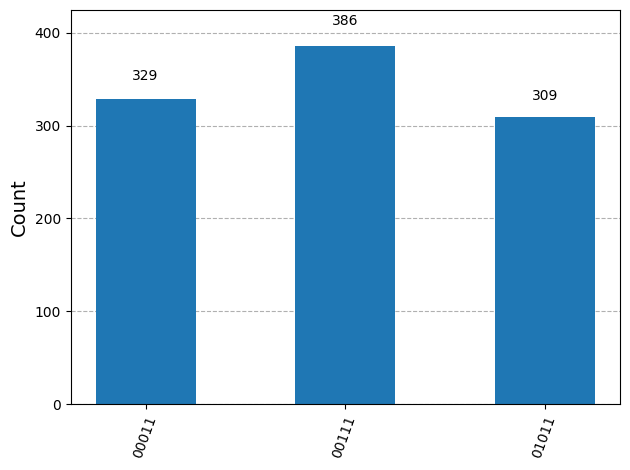

In [12]:
plot_histogram(counts)

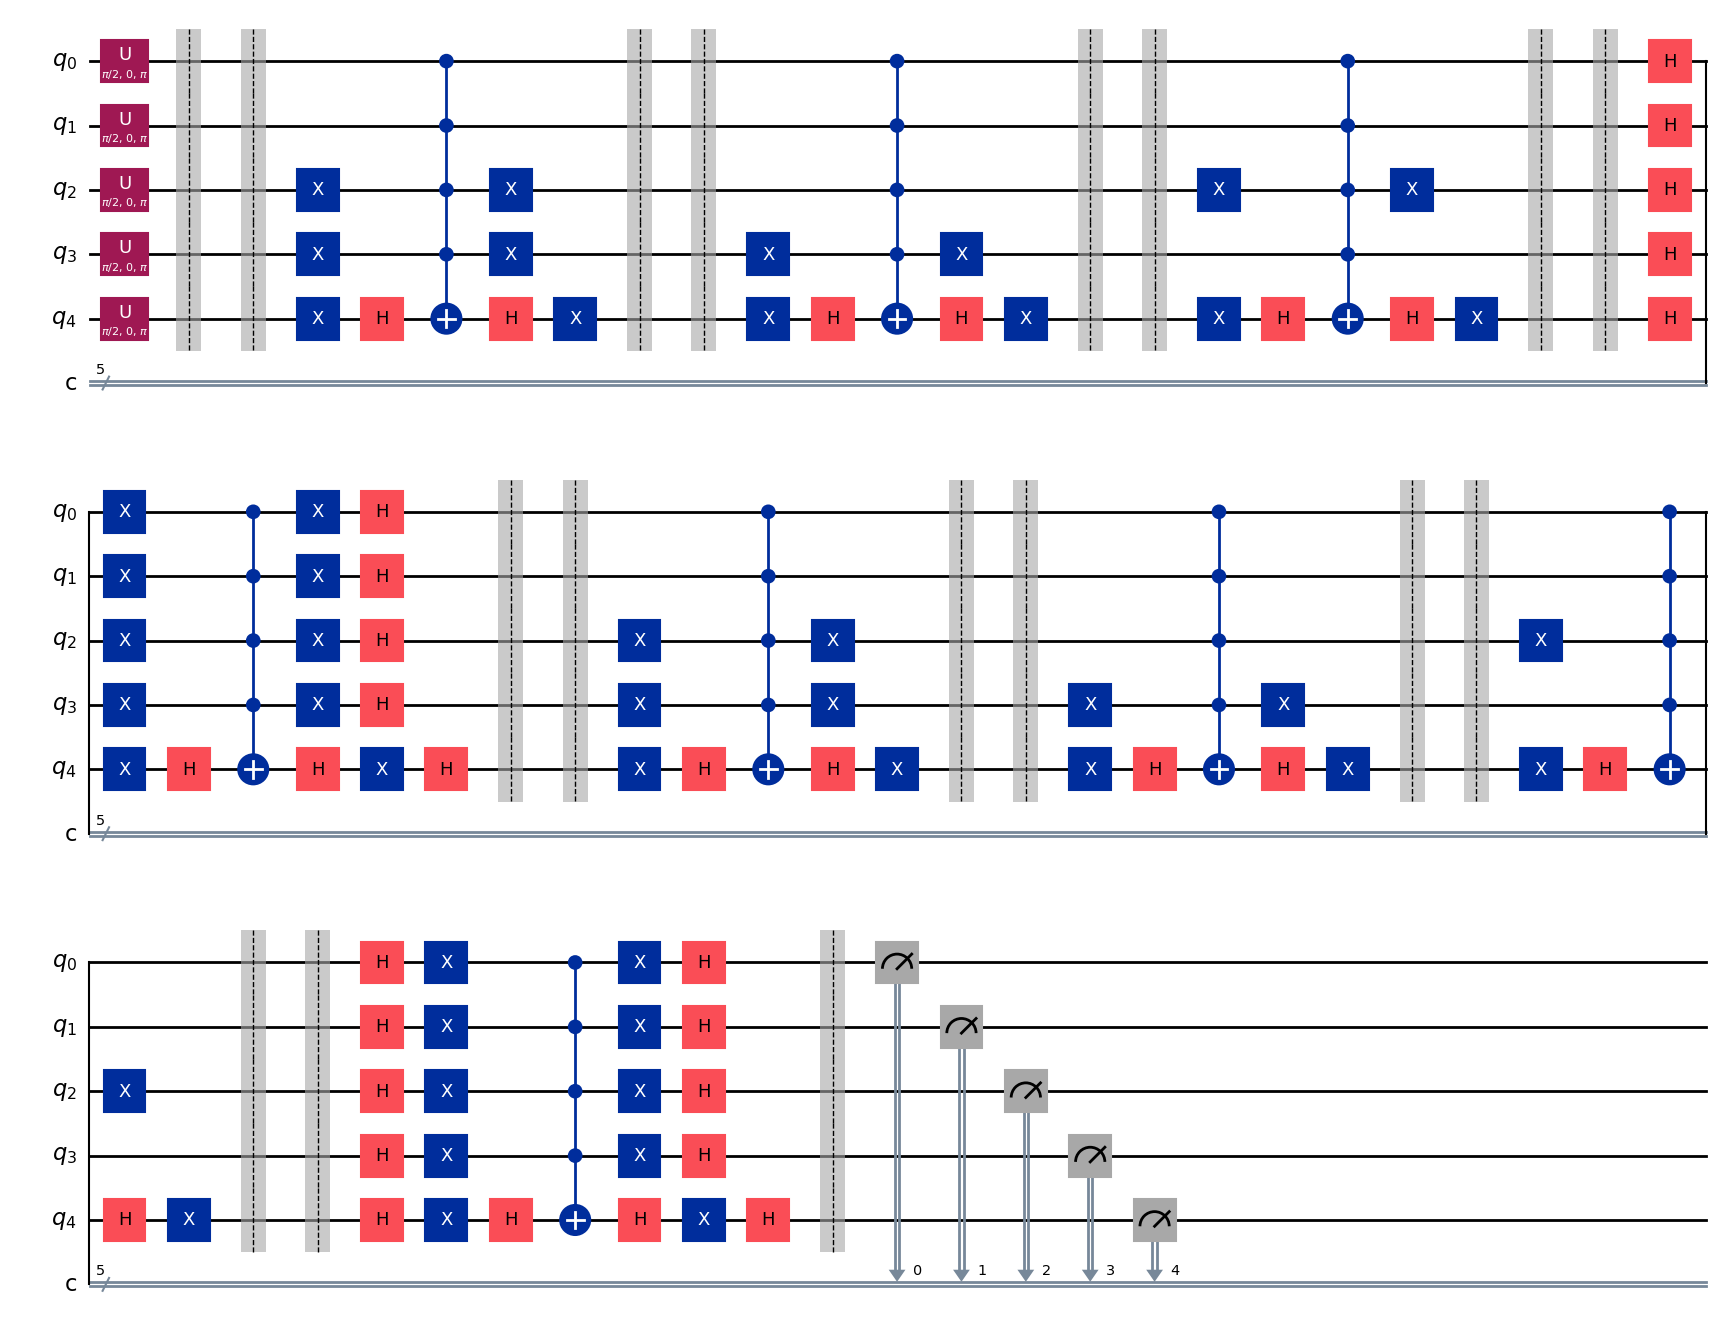

In [13]:
qc.decompose().draw('mpl')